# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Big Data** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Examples on Structured Streaming (Kakfa producer)** </center>
---
**Profesor**: Pablo Camarillo Ramirez

# Create SparkSession

In [1]:
from spark_utils import SparkUtils
from pathlib import Path
import shutil
import pyspark.sql.functions as F

kafka_connector = "org.apache.spark:spark-sql-kafka-0-10_2.13:4.0.0"
su = SparkUtils("Example Kafka", 
                "spark://spark-master:7077",
                spark_packages=kafka_connector)
su.spark


:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2.5.2/cache
The jars for the packages stored in: /root/.ivy2.5.2/jars
org.apache.spark#spark-sql-kafka-0-10_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-dd067679-dcfc-42d4-aa96-497149a1020c;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.13;4.0.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.13;4.0.0 in central
	found org.apache.kafka#kafka-clients;3.9.0 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.7 in central
	found org.slf4j#slf4j-api;2.0.16 in central
	found org.apache.hadoop#hadoop-client-runtime;3.4.1 in central
	found org.apache.hadoop#hadoop-client-api;3.4.1 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.scala-lang.modules#scala-parallel-collections_2.13;1.2.0

In [2]:
pip install kafka-python

Note: you may need to restart the kernel to use updated packages.


# Create a data stream from a Kafka topic

### Create `server-logs` topic

```
    docker exec -it <Kafka container ID> \
     /opt/kafka/bin/kafka-topics.sh \
      --create --zookeeper zookeeper:2181 \
      --replication-factor 1 --partitions 1 \
      --topic server-logs
```

```
    docker exec -it 0cf75da0ca5041b295ed8cee66adb76f233374978df08462f1a714cf961fdf8a /opt/kafka/bin/kafka-topics.sh --create --zookeeper zookeeper:2181 --replication-factor 1 --partitions 1 --topic server-logs
```

In [3]:
# Create the remote connection
kafka_df = su.spark.readStream \
            .format("kafka") \
            .option("kafka.bootstrap.servers", "kafka:9093") \
            .option("subscribe", "kafka-spark-example") \
            .load()

kafka_df.printSchema()

# Transform binary data to string
df_input = kafka_df.selectExpr("CAST(value AS STRING)")

# Clean checkpoint
checkpoint_path = "/opt/spark/work-dir/checkpoints/logs_checkpoint"
dir_path = Path(checkpoint_path)
if dir_path.exists() and dir_path.is_dir():
    shutil.rmtree(dir_path)

words = df_input.select(F.explode(F.split(df_input.value, " ")).alias("word"))
word_count = words.groupBy("word").count()

# Send transformed data to the Sink
query_a = (word_count.writeStream
            .trigger(processingTime='2 second')
            .outputMode("complete")
            .format("console")
            .option("checkpointLocation", checkpoint_path)
            .start())

print("   Press Ctrl+C to stop.\n")
su.spark.streams.awaitAnyTermination()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



26/04/14 00:41:54 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


   Press Ctrl+C to stop.



-------------------------------------------
Batch: 0
-------------------------------------------
+----+-----+
|word|count|
+----+-----+
+----+-----+



26/04/14 00:42:04 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 2000} milliseconds, but spent 10209 milliseconds
ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

## Custom producer

### Run the producer

```
    docker exec -it <Spark-Notebook container ID> /bin/bash

    docker exec -it 770a47485dbc9573356e5b03f3f913477bc8cf5dd8121c5b940513bd101f36d8  /bin/bash
    # cd src/producers/
    # python3 kafka_producer.py --broker kafka:9093 --topic server-logs --records 20
```

### Run the consumer code

In [4]:
# Create the remote connection
server_logs_df = (su.spark.readStream
            .format("kafka")
            .option("kafka.bootstrap.servers", "kafka:9093")
            .option("subscribe", "server-logs")
            .load())

# Transform binary data to string
logs_df = server_logs_df.selectExpr("CAST(value AS STRING)")

# Clean checkpoint
checkpoint_path = "/opt/spark/work-dir/checkpoints/logs_checkpoint"
dir_path = Path(checkpoint_path)
if dir_path.exists() and dir_path.is_dir():
    shutil.rmtree(dir_path)

# Transform original dataframe
parsed_df = (
    logs_df
    .withColumn("parts",     F.split(F.col("value"), r" \| "))
    .withColumn("timestamp", F.to_timestamp(F.col("parts")[0], "yyyy-MM-dd HH:mm:ss"))
    .withColumn("level",     F.trim(F.col("parts")[1]))
    .withColumn("message",   F.trim(F.col("parts")[2]))
    .withColumn("server",    F.trim(F.col("parts")[3]))
    .drop("parts", "value")
    .filter(F.col("timestamp").isNotNull())
)

# Write stream in the destination
output_path = "/opt/spark/work-dir/data/streaming/output/"
query_events = (
    parsed_df.writeStream
    .outputMode("append")
    .format("parquet")
    .option("truncate", False)
    .option("checkpointLocation", checkpoint_path)
    .option("path", output_path)
    .partitionBy("server", "level")
    .start()
)

print("   Press Ctrl+C to stop.\n")
su.spark.streams.awaitAnyTermination()

26/04/14 00:52:28 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


   Press Ctrl+C to stop.



ERROR:root:KeyboardInterrupt while sending command.                             
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705

KeyboardInterrupt: 

```
PS C:\Users\santi> docker exec -it 0cf75da0ca5041b295ed8cee66adb76f233374978df08462f1a714cf961fdf8a /opt/kafka/bin/kafka-topics.sh --create --zookeeper zookeeper:2181 --replication-factor 1 --partitions 1 --topic server-logs    
Error response from daemon: container 0cf75da0ca5041b295ed8cee66adb76f233374978df08462f1a714cf961fdf8a is not running
PS C:\Users\santi> docker exec -it 0cf75da0ca5041b295ed8cee66adb76f233374978df08462f1a714cf961fdf8a /opt/kafka/bin/kafka-topics.sh --create --zookeeper zookeeper:2181 --replication-factor 1 --partitions 1 --topic server-logs    
Error while executing topic command : Topic 'server-logs' already exists.
[2026-04-14 00:40:32,886] ERROR org.apache.kafka.common.errors.TopicExistsException: Topic 'server-logs' already exists.
 (kafka.admin.TopicCommand$)
PS C:\Users\santi>docker exec -it 770a47485dbc9573356e5b03f3f913477bc8cf5dd8121c5b940513bd101f36d8  /bin/bash
Delay between records: 5-15 seconds
-------------------------------------------------------
[1] Sent: 2026-04-14 00:42:43 | WARN  | Memory usage 90% | server-node-2
    Next record in 12s ...
[2] Sent: 2026-04-14 00:42:55 | ERROR | Unhandled exception in worker thread | server-node-5
    Next record in 12s ...
[3] Sent: 2026-04-14 00:43:07 | ERROR | Unhandled exception in worker thread | server-node-2
    Next record in 15s ...
[4] Sent: 2026-04-14 00:43:22 | INFO  | Cache cleared | server-node-4
    Next record in 13s ...
[5] Sent: 2026-04-14 00:43:35 | ERROR | Unhandled exception in worker thread | server-node-5
    Next record in 8s ...
[6] Sent: 2026-04-14 00:43:43 | ERROR | Disk full | server-node-4
    Next record in 7s ...
[7] Sent: 2026-04-14 00:43:50 | WARN  | Response time above threshold | server-node-3
    Next record in 13s ...
[8] Sent: 2026-04-14 00:44:03 | WARN  | Disk usage 85% | server-node-2
    Next record in 9s ...
[9] Sent: 2026-04-14 00:44:12 | WARN  | CPU spike detected | server-node-3
    Next record in 7s ...
[10] Sent: 2026-04-14 00:44:19 | INFO  | Backup completed successfully | server-node-4
    Next record in 9s ...
[11] Sent: 2026-04-14 00:44:28 | WARN  | Disk usage 85% | server-node-4
    Next record in 6s ...
[12] Sent: 2026-04-14 00:44:34 | ERROR | Database connection timeout | server-node-1
    Next record in 8s ...
[13] Sent: 2026-04-14 00:44:42 | WARN  | Certificate expires in 7 days | server-node-2
    Next record in 7s ...
[14] Sent: 2026-04-14 00:44:49 | WARN  | CPU spike detected | server-node-1
    Next record in 12s ...
[15] Sent: 2026-04-14 00:45:01 | ERROR | Disk full | server-node-5
    Next record in 12s ...
[16] Sent: 2026-04-14 00:45:13 | INFO  | Configuration reloaded | server-node-5
    Next record in 13s ...
[17] Sent: 2026-04-14 00:45:26 | WARN  | Certificate expires in 7 days | server-node-5
    Next record in 11s ...
[18] Sent: 2026-04-14 00:45:37 | INFO  | Cache cleared | server-node-1
    Next record in 11s ...
[19] Sent: 2026-04-14 00:45:48 | INFO  | Backup completed successfully | server-node-4
    Next record in 11s ...
[20] Sent: 2026-04-14 00:45:59 | WARN  | Memory usage 90% | server-node-3

Done. Total records sent: 20
root@770a47485dbc:/opt/spark/work-dir/src# python3 kafka_producer.py --broker kafka:9093 --topic server-logs --records 20
Connected to broker : kafka:9093
Topic               : server-logs
Records to send     : 20
Delay between records: 5-15 seconds
-------------------------------------------------------
[1] Sent: 2026-04-14 00:53:09 | INFO  | Configuration reloaded | server-node-2
    Next record in 5s ...
[2] Sent: 2026-04-14 00:53:14 | ERROR | Authentication failed | server-node-4
    Next record in 6s ...
[3] Sent: 2026-04-14 00:53:20 | INFO  | User login successful | server-node-2
    Next record in 10s ...
[4] Sent: 2026-04-14 00:53:30 | ERROR | Authentication failed | server-node-1
    Next record in 9s ...
[5] Sent: 2026-04-14 00:53:39 | INFO  | Configuration reloaded | server-node-3
    Next record in 5s ...
[6] Sent: 2026-04-14 00:53:44 | ERROR | Database connection timeout | server-node-5
    Next record in 12s ...
[7] Sent: 2026-04-14 00:53:56 | WARN  | CPU spike detected | server-node-4
    Next record in 10s ...
[8] Sent: 2026-04-14 00:54:06 | INFO  | Configuration reloaded | server-node-3
    Next record in 6s ...
[9] Sent: 2026-04-14 00:54:13 | ERROR | 404 Not Found | server-node-3
    Next record in 15s ...
[10] Sent: 2026-04-14 00:54:28 | ERROR | Disk full | server-node-1
    Next record in 11s ...
[11] Sent: 2026-04-14 00:54:39 | ERROR | Disk full | server-node-2
    Next record in 10s ...
[12] Sent: 2026-04-14 00:54:49 | ERROR | Unhandled exception in worker thread | server-node-5
    Next record in 6s ...
[13] Sent: 2026-04-14 00:54:55 | WARN  | Retry attempt 3 of 5 | server-node-2
    Next record in 15s ...
[14] Sent: 2026-04-14 00:55:10 | WARN  | Disk usage 85% | server-node-5
    Next record in 14s ...
[15] Sent: 2026-04-14 00:55:24 | INFO  | Backup completed successfully | server-node-3
    Next record in 8s ...
[16] Sent: 2026-04-14 00:55:32 | INFO  | Cache cleared | server-node-1
    Next record in 11s ...
[17] Sent: 2026-04-14 00:55:43 | WARN  | Response time above threshold | server-node-4
    Next record in 8s ...
[18] Sent: 2026-04-14 00:55:51 | INFO  | Cache cleared | server-node-4
    Next record in 14s ...
[19] Sent: 2026-04-14 00:56:05 | WARN  | Memory usage 90% | server-node-5
    Next record in 10s ...
[20] Sent: 2026-04-14 00:56:15 | WARN  | Response time above threshold | server-node-3

Done. Total records sent: 20
root@770a47485dbc:/opt/spark/work-dir/src# 
```

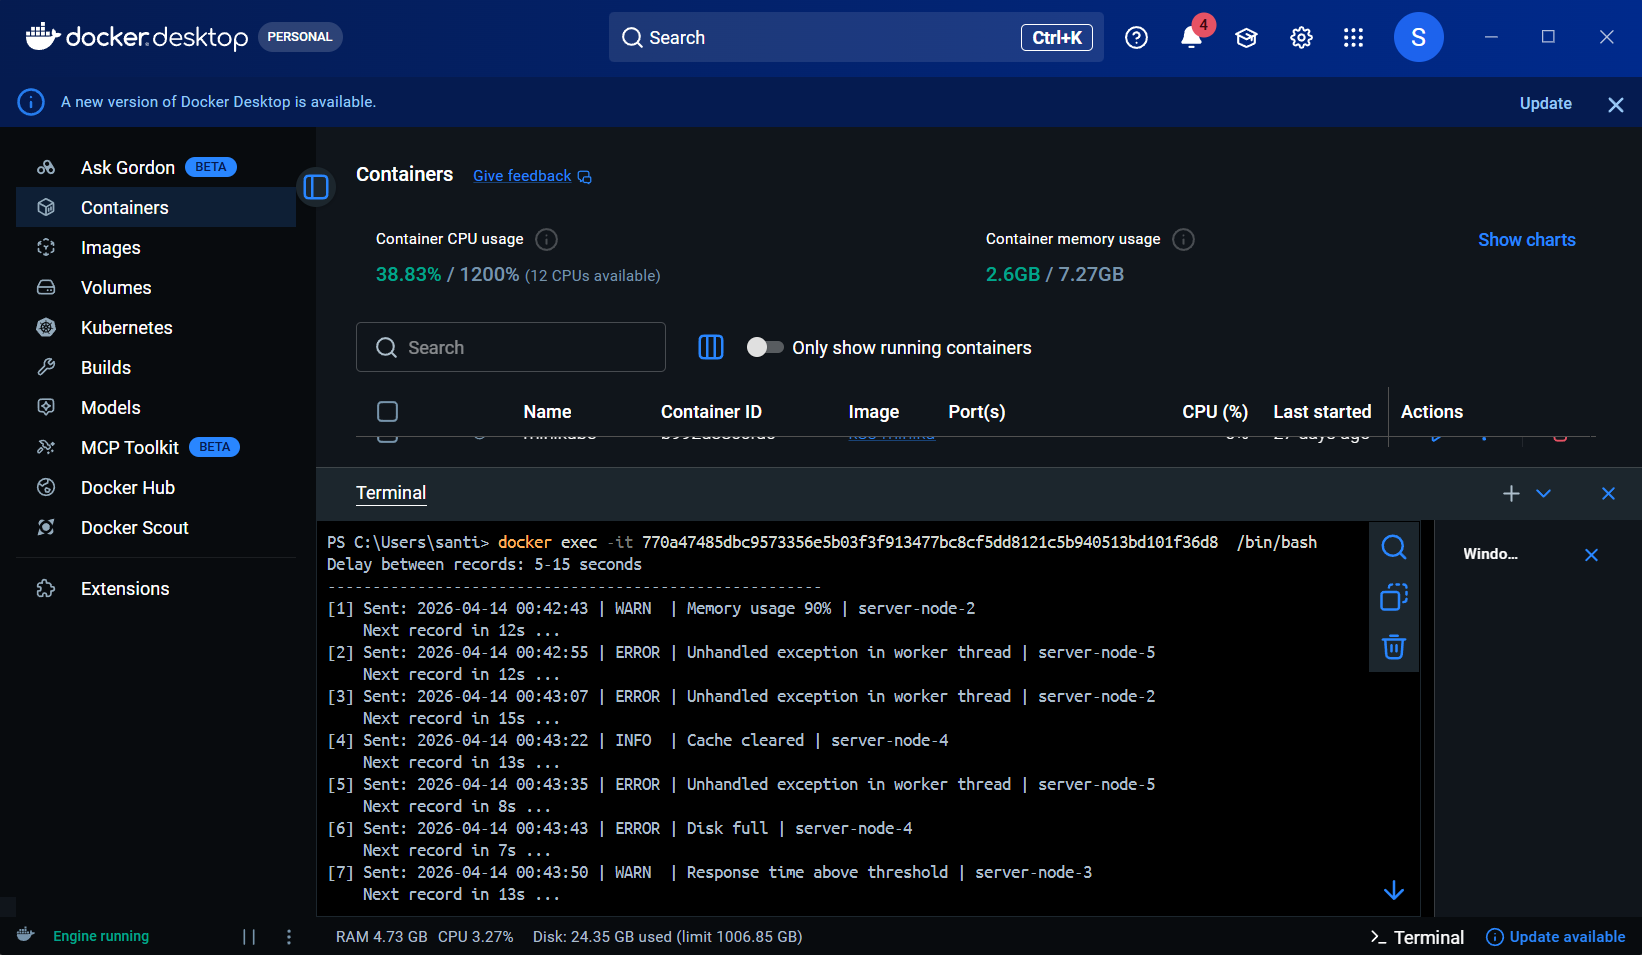

In [5]:
!ls -lah /opt/spark/work-dir/data/streaming/output/

total 0
drwxr-xr-x 1 root root 4.0K Apr 14 00:53  .
drwxr-xr-x 1 root root 4.0K Apr 14 00:52  ..
drwxr-xr-x 1 root root 4.0K Apr 14 00:55 'server=server-node-1'
drwxr-xr-x 1 root root 4.0K Apr 14 00:54 'server=server-node-2'
drwxr-xr-x 1 root root 4.0K Apr 14 00:56 'server=server-node-3'
drwxr-xr-x 1 root root 4.0K Apr 14 00:55 'server=server-node-4'
drwxr-xr-x 1 root root 4.0K Apr 14 00:55 'server=server-node-5'
drwxr-xr-x 1 root root 4.0K Apr 14 00:56  _spark_metadata


In [6]:
su.spark.stop()

26/04/14 01:28:36 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1001 (kafka/172.18.0.2:9093) could not be established. Node may not be available.
26/04/14 01:28:36 WARN NetworkClient: [AdminClient clientId=adminclient-2] Connection to node 1001 (kafka/172.18.0.2:9093) could not be established. Node may not be available.
26/04/14 01:28:36 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1001 (kafka/172.18.0.2:9093) could not be established. Node may not be available.
26/04/14 01:28:36 WARN NetworkClient: [AdminClient clientId=adminclient-2] Connection to node 1001 (kafka/172.18.0.2:9093) could not be established. Node may not be available.
